# Layer 2: S2 vs Predicted Road Condition

This notebook analyzes the relationship between Sentinel-2 road-adjacent indices and `pred_condition` from the **manual validation** sheet.

What this notebook does:
1. Load populated rows with `pred_condition` and S2 data.
2. Engineer temporal features from 2020-2023 quarterly index series.
3. Test correlation between S2/temporal signals and condition (`good` vs `poor`).
4. Train a Random Forest model using S2 features + OSM paved/unpaved (`surface_class`).


In [1]:
# Dependencies check
# If this cell fails, install in your active kernel environment, e.g.:
# pip install pandas numpy matplotlib seaborn scikit-learn openpyxl

import importlib

required = ['numpy', 'pandas', 'matplotlib', 'seaborn', 'sklearn', 'openpyxl']
missing = [m for m in required if importlib.util.find_spec(m) is None]
if missing:
    raise ModuleNotFoundError(
        'Missing packages: ' + ', '.join(missing) +\
        '\nInstall with: pip install ' + ' '.join(missing)
    )

print('All required packages are installed.')


All required packages are installed.


In [ ]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42



In [3]:
# Load workbook
DATA_PATH = Path('../data/named_roads.xlsx')
SHEET = 'manual validation'

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Could not find workbook at {DATA_PATH.resolve()}')

df = pd.read_excel(DATA_PATH, sheet_name=SHEET)
print('Loaded rows:', len(df))
print('Loaded columns:', len(df.columns))


Loaded rows: 17193
Loaded columns: 91


In [4]:
# Identify S2 quarterly columns dynamically
s2_pattern = re.compile(r'^(ndvi|ndmi|ndbi|ndwi|bsi)_(\d{4})_Q([1-4])$')

s2_cols = [c for c in df.columns if s2_pattern.match(str(c))]
index_names = sorted({s2_pattern.match(c).group(1) for c in s2_cols})

print('S2 columns found:', len(s2_cols))
print('Indices:', index_names)

if not s2_cols:
    raise ValueError('No S2 columns found. Check column naming format.')


S2 columns found: 80
Indices: ['bsi', 'ndbi', 'ndmi', 'ndvi', 'ndwi']


In [5]:
# Keep only populated dataset: rows with pred_condition (good/poor) and at least one S2 value
work = df.copy()

work['pred_condition'] = work['pred_condition'].astype(str).str.strip().str.lower()
work = work[work['pred_condition'].isin(['good', 'poor'])].copy()

work['surface_class'] = work.get('surface_class', pd.Series(index=work.index, dtype='object'))
work['surface_class'] = work['surface_class'].astype(str).str.strip().str.lower()
work['surface_paved_binary'] = np.where(work['surface_class'].eq('paved'), 1,
                                 np.where(work['surface_class'].eq('unpaved'), 0, np.nan))

has_s2 = work[s2_cols].notna().any(axis=1)
analysis_df = work[has_s2].copy()
analysis_df['condition_bin'] = (analysis_df['pred_condition'] == 'poor').astype(int)

print('Rows with pred_condition good/poor:', len(work))
print('Rows with pred_condition + any S2:', len(analysis_df))
print('Condition counts:')
print(analysis_df['pred_condition'].value_counts(dropna=False))
print('Surface binary availability:', analysis_df['surface_paved_binary'].notna().mean().round(4))


Rows with pred_condition good/poor: 2743
Rows with pred_condition + any S2: 2548
Condition counts:
pred_condition
good    2488
poor      60
Name: count, dtype: int64
Surface binary availability: 0.7684


In [6]:
# Quick class-by-class snapshot
snapshot = (
    analysis_df.groupby(['road_class', 'pred_condition'], dropna=False)
    .size()
    .rename('count')
    .reset_index()
    .sort_values(['road_class', 'pred_condition'])
)
snapshot.head(20)


,road_class,pred_condition,count
0,primary,good,600
1,primary,poor,16
2,secondary,good,607
3,secondary,poor,11
4,tertiary,good,833
5,tertiary,poor,31
6,trunk,good,448
7,trunk,poor,2


In [7]:
# Temporal feature engineering (per index)

def ordered_cols_for_index(columns, idx_name):
    parsed = []
    for c in columns:
        m = s2_pattern.match(c)
        if m and m.group(1) == idx_name:
            year = int(m.group(2))
            quarter = int(m.group(3))
            parsed.append((year, quarter, c))
    parsed.sort(key=lambda x: (x[0], x[1]))
    return [c for _, _, c in parsed]


def row_slope(vals):
    vals = np.array(vals, dtype=float)
    mask = ~np.isnan(vals)
    if mask.sum() < 4:
        return np.nan
    x = np.arange(len(vals))[mask]
    y = vals[mask]
    return float(np.polyfit(x, y, 1)[0])


def zscore(series):
    std = series.std(ddof=0)
    if pd.isna(std) or std == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - series.mean()) / std


temporal_features = pd.DataFrame(index=analysis_df.index)
years = [2020, 2021, 2022, 2023]

for idx in index_names:
    cols = ordered_cols_for_index(s2_cols, idx)
    if not cols:
        continue

    m = analysis_df[cols].apply(pd.to_numeric, errors='coerce')

    temporal_features[f'{idx}_mean_all'] = m.mean(axis=1)
    temporal_features[f'{idx}_std_all'] = m.std(axis=1)
    temporal_features[f'{idx}_qoq_mean_change'] = m.diff(axis=1).mean(axis=1)
    temporal_features[f'{idx}_slope_per_quarter'] = m.apply(lambda r: row_slope(r.values), axis=1)

    for y in years:
        y_cols = [c for c in cols if f'_{y}_' in c]
        temporal_features[f'{idx}_mean_{y}'] = m[y_cols].mean(axis=1) if y_cols else np.nan

    temporal_features[f'{idx}_yoy_2023_vs_2020'] = (
        temporal_features[f'{idx}_mean_2023'] - temporal_features[f'{idx}_mean_2020']
    )

# Composite degradation-like proxy (higher = more likely worsening)
# Heuristic: higher BSI/NDBI and lower NDMI/NDVI tend to align with worse surface/environment context.
temporal_features['temporal_degradation_score'] = (
    zscore(temporal_features.get('bsi_yoy_2023_vs_2020', pd.Series(index=analysis_df.index, dtype=float)).fillna(0))
    + zscore(temporal_features.get('ndbi_yoy_2023_vs_2020', pd.Series(index=analysis_df.index, dtype=float)).fillna(0))
    - zscore(temporal_features.get('ndmi_yoy_2023_vs_2020', pd.Series(index=analysis_df.index, dtype=float)).fillna(0))
    - zscore(temporal_features.get('ndvi_yoy_2023_vs_2020', pd.Series(index=analysis_df.index, dtype=float)).fillna(0))
)

enriched = pd.concat([analysis_df, temporal_features], axis=1)
print('Temporal features created:', temporal_features.shape[1])
enriched[['pred_condition', 'condition_bin', 'temporal_degradation_score']].head()


Temporal features created: 46


,pred_condition,condition_bin,temporal_degradation_score
20,good,0,1.419657
104,good,0,2.458691
112,good,0,-4.323306
113,good,0,-2.755018
114,good,0,-2.822474


In [8]:
# Correlation with predicted condition (point-biserial equivalent via Pearson with binary target)

numeric_candidates = [
    c for c in list(s2_cols) + list(temporal_features.columns)
    if c in enriched.columns and pd.api.types.is_numeric_dtype(enriched[c])
]

corr_df = (
    enriched[numeric_candidates + ['condition_bin']]
    .corr(numeric_only=True)['condition_bin']
    .drop('condition_bin')
    .dropna()
    .to_frame('corr_with_poor')
)
corr_df['abs_corr'] = corr_df['corr_with_poor'].abs()
corr_df = corr_df.sort_values('abs_corr', ascending=False)

print('Top 25 absolute correlations with poor condition:')
display(corr_df.head(25))


Top 25 absolute correlations with poor condition:


,corr_with_poor,abs_corr
ndwi_2020_Q3,-0.079279,0.079279
bsi_2021_Q3,0.076996,0.076996
ndvi_2020_Q3,0.069032,0.069032
ndwi_2023_Q2,-0.067161,0.067161
ndbi_2021_Q3,0.067124,0.067124
ndmi_2021_Q3,-0.067124,0.067124
ndvi_2023_Q2,0.066789,0.066789
bsi_slope_per_quarter,-0.065148,0.065148
ndwi_2021_Q3,-0.063263,0.063263
ndbi_slope_per_quarter,-0.062558,0.062558


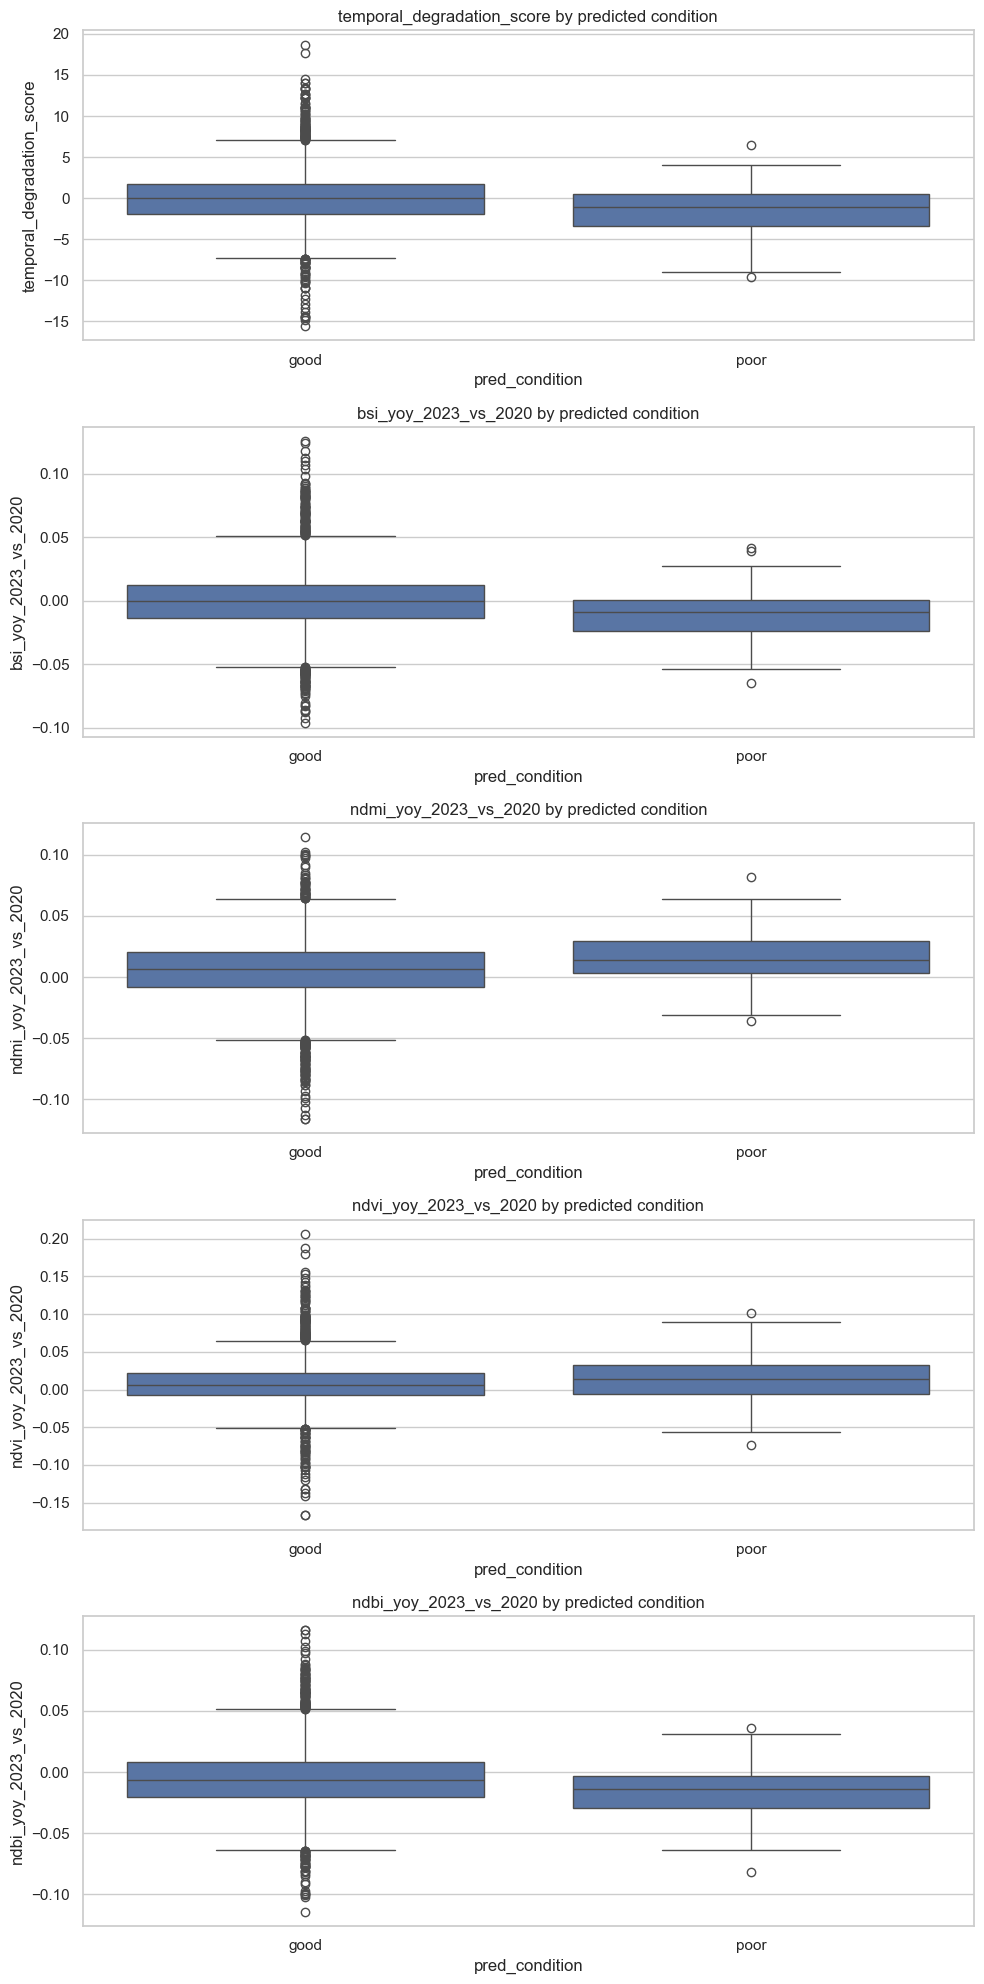

In [9]:
# Visual check: key temporal features by condition
plot_features = [
    c for c in [
        'temporal_degradation_score',
        'bsi_yoy_2023_vs_2020',
        'ndmi_yoy_2023_vs_2020',
        'ndvi_yoy_2023_vs_2020',
        'ndbi_yoy_2023_vs_2020',
    ]
    if c in enriched.columns
]

if plot_features:
    fig, axes = plt.subplots(len(plot_features), 1, figsize=(10, 4 * len(plot_features)))
    if len(plot_features) == 1:
        axes = [axes]
    for ax, feat in zip(axes, plot_features):
        sns.boxplot(data=enriched, x='pred_condition', y=feat, ax=ax)
        ax.set_title(f'{feat} by predicted condition')
    plt.tight_layout()
    plt.show()
else:
    print('No plot features available.')


Model rows: 2548
Positive class (poor) rate: 0.0235
Train class counts (original):
condition_bin
0    1399
1      34
Name: count, dtype: int64
Train class counts (oversampled):
condition_bin
1    1399
0    1399
Name: count, dtype: int64
Selected threshold: 0.05


,threshold,f1_poor,recall_poor,precision_poor,balanced_acc
3,0.20,0.200000,0.272727,0.157895,0.619233
2,0.15,0.186047,0.363636,0.125000,0.651840
4,0.25,0.173913,0.181818,0.166667,0.580202
11,0.60,0.142857,0.090909,0.333333,0.543313
9,0.50,0.133333,0.090909,0.250000,0.542243
10,0.55,0.133333,0.090909,0.250000,0.542243
7,0.40,0.125000,0.090909,0.200000,0.541172
8,0.45,0.125000,0.090909,0.200000,0.541172
1,0.10,0.115942,0.363636,0.068966,0.624002
0,0.05,0.105263,0.636364,0.057377,0.695055


Balanced Accuracy: 0.5947
ROC AUC: 0.6503
PR AUC: 0.0398
Poor recall: 0.4
Poor precision: 0.0438
Poor F1: 0.0789

Classification report:
              precision    recall  f1-score   support

        good       0.98      0.79      0.88       622
        poor       0.04      0.40      0.08        15

    accuracy                           0.78       637
   macro avg       0.51      0.59      0.48       637
weighted avg       0.96      0.78      0.86       637



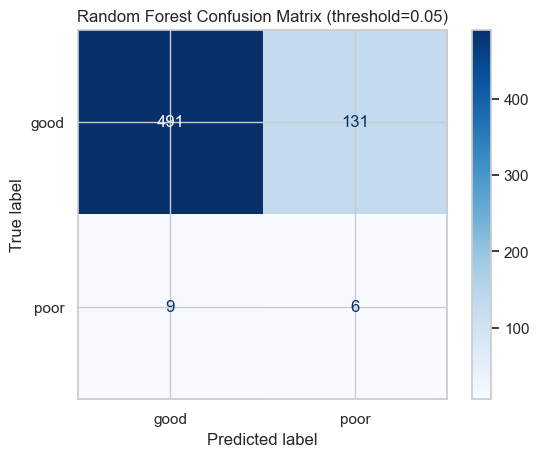

Top 25 feature importances:


,importance
bsi_2021_Q3,0.032439
bsi_2022_Q1,0.030605
bsi_2022_Q2,0.028675
ndbi_2021_Q3,0.027737
ndwi_2020_Q3,0.026626
bsi_2020_Q2,0.025747
ndmi_2021_Q3,0.025692
ndbi_2020_Q2,0.025098
bsi_2021_Q4,0.024461
ndvi_2022_Q1,0.024003


In [10]:
# Random Forest: S2 + paved/unpaved feature -> predict poor/good (imbalance-aware)
rf_features = s2_cols + ['surface_paved_binary']
X = enriched[rf_features].apply(pd.to_numeric, errors='coerce')
y = enriched['condition_bin'].astype(int)

valid_target = y.notna()
X = X.loc[valid_target]
y = y.loc[valid_target]

print('Model rows:', len(X))
print('Positive class (poor) rate:', round(y.mean(), 4))

# Split into train/validation/test to tune threshold on validation only.
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=RANDOM_STATE, stratify=y_trainval
)


def oversample_minority(X_in, y_in, random_state=42):
    # Simple random oversampling for minority class (train only).
    x = X_in.copy()
    y_s = y_in.copy()
    cls_counts = y_s.value_counts()
    if len(cls_counts) < 2:
        return x, y_s

    maj_cls = cls_counts.idxmax()
    min_cls = cls_counts.idxmin()
    n_to_add = cls_counts[maj_cls] - cls_counts[min_cls]
    if n_to_add <= 0:
        return x, y_s

    min_idx = y_s[y_s == min_cls].index
    sampled_idx = np.random.default_rng(random_state).choice(min_idx, size=n_to_add, replace=True)

    x_bal = pd.concat([x, x.loc[sampled_idx]], axis=0)
    y_bal = pd.concat([y_s, y_s.loc[sampled_idx]], axis=0)

    shuffled = np.random.default_rng(random_state).permutation(len(x_bal))
    x_bal = x_bal.iloc[shuffled].reset_index(drop=True)
    y_bal = y_bal.iloc[shuffled].reset_index(drop=True)
    return x_bal, y_bal


X_train_bal, y_train_bal = oversample_minority(X_train, y_train, random_state=RANDOM_STATE)
print('Train class counts (original):')
print(y_train.value_counts())
print('Train class counts (oversampled):')
print(y_train_bal.value_counts())

clf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('rf', RandomForestClassifier(
        n_estimators=600,
        random_state=RANDOM_STATE,
        class_weight='balanced_subsample',
        min_samples_leaf=2,
        n_jobs=-1,
    )),
])

clf.fit(X_train_bal, y_train_bal)

# Validation threshold tuning for poor-class F1 with recall guardrail
val_proba = clf.predict_proba(X_val)[:, 1]
thresholds = np.arange(0.05, 0.95, 0.05)
rows = []
for t in thresholds:
    p = (val_proba >= t).astype(int)
    rows.append({
        'threshold': round(float(t), 2),
        'f1_poor': f1_score(y_val, p, pos_label=1, zero_division=0),
        'recall_poor': recall_score(y_val, p, pos_label=1, zero_division=0),
        'precision_poor': precision_score(y_val, p, pos_label=1, zero_division=0),
        'balanced_acc': balanced_accuracy_score(y_val, p),
    })

tune_df = pd.DataFrame(rows)

# Prefer thresholds with recall >= 0.50; otherwise best F1 overall.
cand = tune_df[tune_df['recall_poor'] >= 0.50]
if len(cand) > 0:
    best = cand.sort_values(['f1_poor', 'balanced_acc'], ascending=False).iloc[0]
else:
    best = tune_df.sort_values(['f1_poor', 'balanced_acc'], ascending=False).iloc[0]

best_threshold = float(best['threshold'])
print('Selected threshold:', best_threshold)
display(tune_df.sort_values(['f1_poor', 'balanced_acc'], ascending=False).head(10))

# Final test evaluation
proba = clf.predict_proba(X_test)[:, 1]
pred = (proba >= best_threshold).astype(int)

print('Balanced Accuracy:', round(balanced_accuracy_score(y_test, pred), 4))
print('ROC AUC:', round(roc_auc_score(y_test, proba), 4))
print('PR AUC:', round(average_precision_score(y_test, proba), 4))
print('Poor recall:', round(recall_score(y_test, pred, pos_label=1, zero_division=0), 4))
print('Poor precision:', round(precision_score(y_test, pred, pos_label=1, zero_division=0), 4))
print('Poor F1:', round(f1_score(y_test, pred, pos_label=1, zero_division=0), 4))
print('\nClassification report:')
print(classification_report(y_test, pred, target_names=['good', 'poor'], zero_division=0))

cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm, display_labels=['good', 'poor']).plot(cmap='Blues', values_format='d')
plt.title(f'Random Forest Confusion Matrix (threshold={best_threshold:.2f})')
plt.show()

rf_model = clf.named_steps['rf']
imputer = clf.named_steps['imputer']

# SimpleImputer can drop all-NaN columns, so align importances to retained feature names.
try:
    rf_feature_names = imputer.get_feature_names_out(rf_features)
except Exception:
    rf_feature_names = X_train.columns[:len(rf_model.feature_importances_)]

importances = pd.Series(
    rf_model.feature_importances_,
    index=rf_feature_names,
).sort_values(ascending=False)

print('Top 25 feature importances:')
display(importances.head(25).to_frame('importance'))


Logistic selected threshold: 0.25


,threshold,f1_poor,recall_poor,precision_poor,balanced_acc
14,0.75,0.113208,0.200000,0.078947,0.562203
8,0.45,0.110236,0.466667,0.062500,0.619942
7,0.40,0.099291,0.466667,0.055556,0.604824
13,0.70,0.096774,0.200000,0.063830,0.552484
15,0.80,0.093023,0.133333,0.071429,0.538589
9,0.50,0.091743,0.333333,0.053191,0.570554
12,0.65,0.084507,0.200000,0.053571,0.542765
10,0.55,0.084211,0.266667,0.050000,0.551260
6,0.35,0.082353,0.466667,0.045161,0.573506
4,0.25,0.074766,0.533333,0.040201,0.560403


Logistic Balanced Accuracy: 0.6227
Logistic ROC AUC: 0.7628
Logistic PR AUC: 0.1971
Logistic Poor recall: 0.7
Logistic Poor precision: 0.0475
Logistic Poor F1: 0.0889

Logistic classification report:
              precision    recall  f1-score   support

        good       0.98      0.55      0.70       618
        poor       0.05      0.70      0.09        20

    accuracy                           0.55       638
   macro avg       0.51      0.62      0.40       638
weighted avg       0.95      0.55      0.68       638



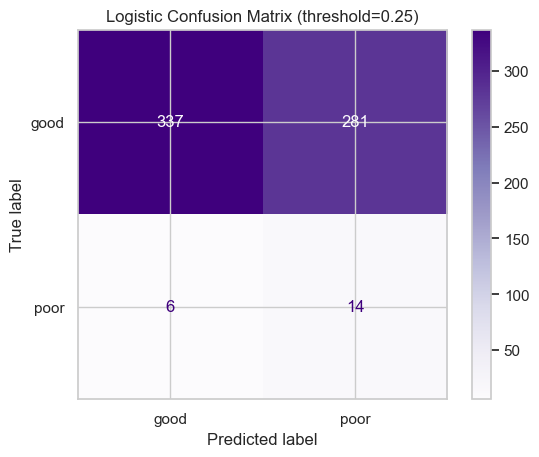

In [24]:
# Logistic Regression: same split/features for comparison
# Reuse X_trainval/X_test/y_trainval/y_test and X_train/X_val/y_train/y_val from RF cell.

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X_train_bal_lr, y_train_bal_lr = oversample_minority(X_train, y_train, random_state=RANDOM_STATE)

logit = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        random_state=RANDOM_STATE,
        class_weight='balanced',
        max_iter=3000,
    )),
])

logit.fit(X_train_bal_lr, y_train_bal_lr)

# Validation threshold tuning
val_proba_lr = logit.predict_proba(X_val)[:, 1]
thresholds = np.arange(0.05, 0.95, 0.05)
rows_lr = []
for t in thresholds:
    p = (val_proba_lr >= t).astype(int)
    rows_lr.append({
        'threshold': round(float(t), 2),
        'f1_poor': f1_score(y_val, p, pos_label=1, zero_division=0),
        'recall_poor': recall_score(y_val, p, pos_label=1, zero_division=0),
        'precision_poor': precision_score(y_val, p, pos_label=1, zero_division=0),
        'balanced_acc': balanced_accuracy_score(y_val, p),
    })

tune_lr = pd.DataFrame(rows_lr)
cand_lr = tune_lr[tune_lr['recall_poor'] >= 0.50]
if len(cand_lr) > 0:
    best_lr = cand_lr.sort_values(['f1_poor', 'balanced_acc'], ascending=False).iloc[0]
else:
    best_lr = tune_lr.sort_values(['f1_poor', 'balanced_acc'], ascending=False).iloc[0]

best_threshold_lr = float(best_lr['threshold'])
print('Logistic selected threshold:', best_threshold_lr)
display(tune_lr.sort_values(['f1_poor', 'balanced_acc'], ascending=False).head(10))

proba_lr = logit.predict_proba(X_test)[:, 1]
pred_lr = (proba_lr >= best_threshold_lr).astype(int)

print('Logistic Balanced Accuracy:', round(balanced_accuracy_score(y_test, pred_lr), 4))
print('Logistic ROC AUC:', round(roc_auc_score(y_test, proba_lr), 4))
print('Logistic PR AUC:', round(average_precision_score(y_test, proba_lr), 4))
print('Logistic Poor recall:', round(recall_score(y_test, pred_lr, pos_label=1, zero_division=0), 4))
print('Logistic Poor precision:', round(precision_score(y_test, pred_lr, pos_label=1, zero_division=0), 4))
print('Logistic Poor F1:', round(f1_score(y_test, pred_lr, pos_label=1, zero_division=0), 4))
print('\nLogistic classification report:')
print(classification_report(y_test, pred_lr, target_names=['good', 'poor'], zero_division=0))

cm_lr = confusion_matrix(y_test, pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['good', 'poor']).plot(cmap='Purples', values_format='d')
plt.title(f'Logistic Confusion Matrix (threshold={best_threshold_lr:.2f})')
plt.show()


In [25]:
# Slice performance by paved/unpaved availability
result = X_test.copy()
result['y_true'] = y_test.values
result['y_pred'] = pred

for label, sub in [('paved=1', result[result['surface_paved_binary'] == 1]),
                   ('unpaved=0', result[result['surface_paved_binary'] == 0]),
                   ('surface missing', result[result['surface_paved_binary'].isna()])]:
    if len(sub) == 0:
        continue
    ba = balanced_accuracy_score(sub['y_true'], sub['y_pred'])
    print(f'{label}: n={len(sub)}, balanced_accuracy={ba:.4f}')


paved=1: n=485, balanced_accuracy=0.5940
unpaved=0: n=4, balanced_accuracy=0.7500
surface missing: n=149, balanced_accuracy=0.6542


## Notes

- `pred_condition` is highly imbalanced (many more `good` than `poor`), so prioritize **balanced accuracy**, **PR AUC**, and poor-class recall over plain accuracy.
- Correlation results are associative, not causal.
- Next step once manual labels are finalized: rerun this exact pipeline using human-validated condition labels and compare performance shift.


## Cross-Validation Check

5-fold stratified CV using the same Layer-2 RF pipeline and threshold-tuning logic (train/validation within each fold).

In [12]:
# Cross-validation evaluation (RF + threshold tuning)
# Uses enriched, s2_cols, and surface_paved_binary from previous cells.

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

rf_features_cv = s2_cols + ['surface_paved_binary']
Xcv = enriched[rf_features_cv].apply(pd.to_numeric, errors='coerce')
ycv = enriched['condition_bin'].astype(int)

valid_target = ycv.notna()
Xcv = Xcv.loc[valid_target].reset_index(drop=True)
ycv = ycv.loc[valid_target].reset_index(drop=True)

print('CV rows:', len(Xcv), 'poor rate:', round(ycv.mean(), 4))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []

for fold, (tr_idx, te_idx) in enumerate(skf.split(Xcv, ycv), start=1):
    X_tr_all = Xcv.iloc[tr_idx].copy()
    y_tr_all = ycv.iloc[tr_idx].copy()
    X_te = Xcv.iloc[te_idx].copy()
    y_te = ycv.iloc[te_idx].copy()

    # inner split for threshold tuning
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_tr_all, y_tr_all,
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=y_tr_all,
    )

    X_tr_bal, y_tr_bal = oversample_minority(X_tr, y_tr, random_state=RANDOM_STATE + fold)

    clf_cv = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('rf', RandomForestClassifier(
            n_estimators=600,
            random_state=RANDOM_STATE,
            class_weight='balanced_subsample',
            min_samples_leaf=2,
            n_jobs=-1,
        )),
    ])

    clf_cv.fit(X_tr_bal, y_tr_bal)

    # tune threshold on validation
    val_proba = clf_cv.predict_proba(X_val)[:, 1]
    thresholds = np.arange(0.05, 0.95, 0.05)
    tune = []
    for t in thresholds:
        p = (val_proba >= t).astype(int)
        tune.append({
            'threshold': float(t),
            'f1_poor': f1_score(y_val, p, pos_label=1, zero_division=0),
            'recall_poor': recall_score(y_val, p, pos_label=1, zero_division=0),
            'precision_poor': precision_score(y_val, p, pos_label=1, zero_division=0),
            'balanced_acc': balanced_accuracy_score(y_val, p),
        })
    tune_df = pd.DataFrame(tune)

    cand = tune_df[tune_df['recall_poor'] >= 0.50]
    if len(cand) > 0:
        best = cand.sort_values(['f1_poor', 'balanced_acc'], ascending=False).iloc[0]
    else:
        best = tune_df.sort_values(['f1_poor', 'balanced_acc'], ascending=False).iloc[0]
    thr = float(best['threshold'])

    # evaluate on fold test
    proba = clf_cv.predict_proba(X_te)[:, 1]
    pred = (proba >= thr).astype(int)

    rows.append({
        'fold': fold,
        'threshold': thr,
        'balanced_accuracy': balanced_accuracy_score(y_te, pred),
        'roc_auc': roc_auc_score(y_te, proba),
        'pr_auc': average_precision_score(y_te, proba),
        'poor_recall': recall_score(y_te, pred, pos_label=1, zero_division=0),
        'poor_precision': precision_score(y_te, pred, pos_label=1, zero_division=0),
        'poor_f1': f1_score(y_te, pred, pos_label=1, zero_division=0),
        'predicted_poor': int(pred.sum()),
        'true_poor': int(y_te.sum()),
        'fold_size': int(len(y_te)),
    })

cv_df = pd.DataFrame(rows)
summary = cv_df.drop(columns=['fold']).agg(['mean', 'std']).T

print('Fold metrics:')
display(cv_df)
print('CV summary (mean ± std):')
display(summary)


CV rows: 2548 poor rate: 0.0235
Fold metrics:


,fold,threshold,balanced_accuracy,roc_auc,pr_auc,poor_recall,poor_precision,poor_f1,predicted_poor,true_poor,fold_size
0,1,0.05,0.672189,0.688002,0.084354,0.583333,0.055556,0.101449,126,12,510
1,2,0.05,0.538153,0.605171,0.041912,0.333333,0.030303,0.055556,132,12,510
2,3,0.05,0.601908,0.644913,0.057710,0.416667,0.045045,0.081301,111,12,510
3,4,0.05,0.566482,0.669517,0.099567,0.416667,0.034247,0.063291,146,12,509
4,5,0.05,0.721663,0.775319,0.062421,0.666667,0.067227,0.122137,119,12,509


CV summary (mean ± std):


,mean,std
threshold,0.050000,0.000000
balanced_accuracy,0.620079,0.075746
roc_auc,0.676584,0.063308
pr_auc,0.069193,0.022773
poor_recall,0.483333,0.136931
poor_precision,0.046475,0.015217
poor_f1,0.084747,0.027392
predicted_poor,126.800000,13.292855
true_poor,12.000000,0.000000
fold_size,509.600000,0.547723
